<a href="https://colab.research.google.com/github/ackuyucu/Ekoloji_Lab/blob/main/Genetik_Suruklenme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

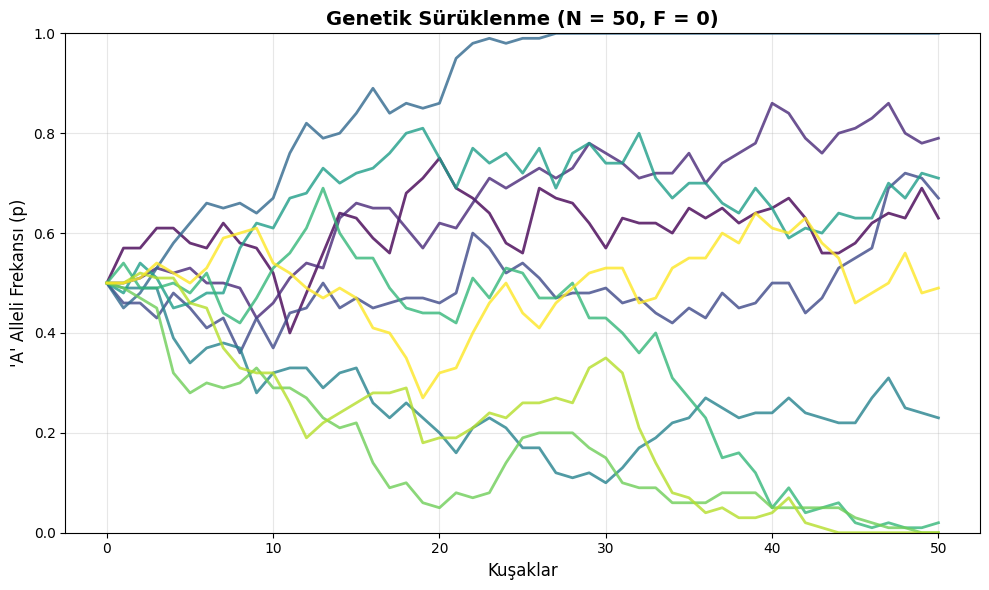

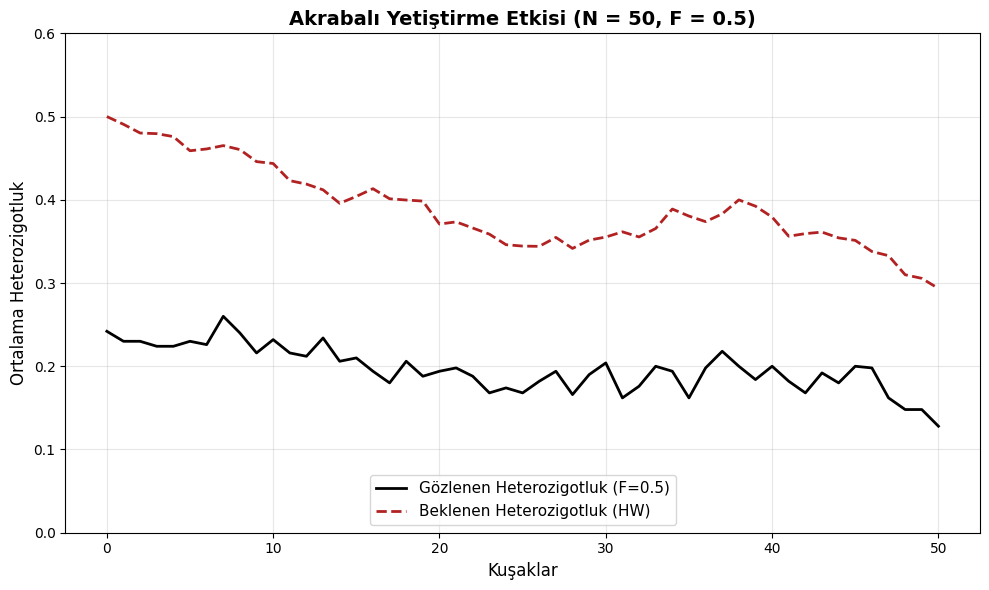

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tekrarlanabilirlik için
np.random.seed(42)

def simulate_drift_inbreeding(N, p0, F_coeff=0, generations=50, replicates=10):
    """Genetik sürüklenme ve akrabalı yetiştirmeyi simüle eder."""
    results = []

    for rep in range(1, replicates + 1):
        p = p0

        for gen in range(generations + 1):
            q = 1 - p

            # Akrabalı yetiştirme (F) dahil edilerek beklenen genotip frekansları
            prob_AA = max((p**2) + (F_coeff * p * q), 0)
            prob_Aa = max((2 * p * q) * (1 - F_coeff), 0)
            prob_aa = max((q**2) + (F_coeff * p * q), 0)

            # Olasılıkları normalize etme (toplam 1 olmalı)
            total_prob = prob_AA + prob_Aa + prob_aa
            probs = [prob_AA / total_prob, prob_Aa / total_prob, prob_aa / total_prob]

            # Genotipleri örnekleme (Sürüklenme tam olarak burada gerçekleşir)
            sampled_genotypes = np.random.choice(["AA", "Aa", "aa"], size=N, replace=True, p=probs)

            n_AA = np.sum(sampled_genotypes == "AA")
            n_Aa = np.sum(sampled_genotypes == "Aa")

            # Gözlenen ve beklenen heterozigotluk
            obs_het = n_Aa / N
            exp_het = 2 * p * q

            results.append({
                "Replicate": rep,
                "Generation": gen,
                "Freq_A": p,
                "Obs_Het": obs_het,
                "Exp_Het": exp_het
            })

            # Yeni p değerini hesaplama ve güncelleme
            p_new = ((2 * n_AA) + n_Aa) / (2 * N)
            p = p_new

            # Sabitlenme veya kaybolma durumu
            if p == 0 or p == 1:
                p = round(p)

    return pd.DataFrame(results)

# ==========================================
# SİMÜLASYONLAR VE GÖRSELLEŞTİRME
# ==========================================

# Senaryo 1: Sadece Sürüklenme (N=50, F=0)
sim_drift_only = simulate_drift_inbreeding(N=50, p0=0.5, F_coeff=0, generations=50, replicates=10)

plt.figure(figsize=(10, 6))
sns.lineplot(data=sim_drift_only, x="Generation", y="Freq_A", hue="Replicate", palette="viridis", legend=False, linewidth=2, alpha=0.8)
plt.ylim(0, 1)
plt.title("Genetik Sürüklenme (N = 50, F = 0)", fontsize=14, fontweight="bold")
plt.xlabel("Kuşaklar", fontsize=12)
plt.ylabel("'A' Alleli Frekansı (p)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Senaryo 2: Sürüklenme + Yüksek Akrabalı Yetiştirme (N=50, F=0.5)
sim_drift_inbreeding = simulate_drift_inbreeding(N=50, p0=0.5, F_coeff=0.5, generations=50, replicates=10)

# Replikasyonların ortalamasını alma
summary_het = sim_drift_inbreeding.groupby("Generation")[["Obs_Het", "Exp_Het"]].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(summary_het["Generation"], summary_het["Obs_Het"], label="Gözlenen Heterozigotluk (F=0.5)", color="black", linewidth=2)
plt.plot(summary_het["Generation"], summary_het["Exp_Het"], label="Beklenen Heterozigotluk (HW)", color="firebrick", linestyle="--", linewidth=2)
plt.ylim(0, 0.6)
plt.title("Akrabalı Yetiştirme Etkisi (N = 50, F = 0.5)", fontsize=14, fontweight="bold")
plt.xlabel("Kuşaklar", fontsize=12)
plt.ylabel("Ortalama Heterozigotluk", fontsize=12)
plt.legend(loc="lower center", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()